In [3]:
import numpy as np
import matplotlib.pyplot as plt

def custom_least_squares(x, y): #Using a function allows me to be able to input whatever values of x or y I need to later on
    n = len(x)
    
    sum_x  = np.sum(x)
    sum_y  = np.sum(y)
    sum_xsquared = np.sum(x**2)
    sum_xy = np.sum(x * y) #All of these calcuate the method of algorithm steps
    
    m = (n * np.sum(x*y) - np.sum(x)*np.sum(y)) / (n * np.sum(x**2) - (np.sum(x))**2)
    b = (np.sum(y) - m * np.sum(x)) / n #It then solves the two linear equations for m and c.
    return m, b

# 1. Create Data
x = np.linspace(0, 1, 101)
noise = np.random.uniform(0, 1, size=len(x)) # Random between 0 and 1
m_true, b_true = 4, 3
y = m_true * x + b_true + noise #These lines create the random linear data. It first goes through and creates x values between 1 and 0 with a step of .01, then creates random values of "noise" between 0 and 1 for randomness, then

m_custom, b_custom = custom_least_squares(x, y)#This runs the custom method

A = np.vstack([x, np.ones(len(x))]).T
m_numpy, b_numpy = np.linalg.lstsq(A, y, rcond=None)[0]

y_custom_pred = m_custom * x + b_custom #Calculates the Y predicted and residuals (actual - predicted)
y_numpy_pred = m_numpy * x + b_numpy
residuals = y - y_custom_pred

idx_max = np.argmax(np.abs(residuals))#This command is what identifies the points with largest and smallest absolute residual errors
idx_min = np.argmin(np.abs(residuals))

print(f"Custom Results: Slope = {m_custom:.4f}, Intercept={b_custom:.4f}")
print(f"Numpy Results: Slope = {m_numpy:.4f}, Intercept={b_numpy:.4f}")
print(f"Largest Error at x={x[idx_max]:.2f}: {residuals[idx_max]:.4f}")
print(f"Smallest Error at x={x[idx_min]:.2f}: {residuals[idx_min]:.4f}")

Custom Results: Slope = 4.0250, Intercept=3.4628
Numpy Results: Slope = 4.0250, Intercept=3.4628
Largest Error at x=0.74: -0.4791
Smallest Error at x=0.71: 0.0030


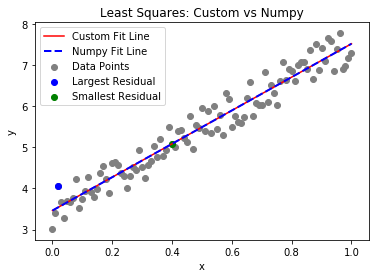

In [2]:
plt.scatter(x, y, color='gray', label='Data Points')
plt.plot(x, y_custom_pred, color='red', label='Custom Fit Line')
plt.plot(x, y_numpy_pred, color='blue', linestyle='--', linewidth=2, label='Numpy Fit Line')

plt.scatter(x[idx_max], y[idx_max], color='blue', label='Largest Residual')
plt.scatter(x[idx_min], y[idx_min], color='green', label='Smallest Residual')# This just highlights the max/min error points

plt.title('Least Squares: Custom vs Numpy')
plt.xlabel('x')
plt.ylabel('y')
plt.legend()
plt.show()